# MC-DCNN over the full TS - Final run
- Use ROC-AUC as metric.
- Add kernel initializers
- Reduce regularization to allow the model to learn more
- More aggressive Early Stopping callback
- Reduced Search Space

In [1]:
import os
# Make sure XLA is OFF (Metal doesn't support XLA/JIT)
# os.environ.pop("TF_XLA_FLAGS", None)
# os.environ.pop("XLA_FLAGS", None)
# os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"


import tensorflow as tf
# tf.config.optimizer.set_jit(False)
print("GPUs:", tf.config.list_physical_devices("GPU"))


import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    average_precision_score,
    PrecisionRecallDisplay,
    accuracy_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score
)

import kineticstoolkit as ktk

import random
import pickle
import json
from typing import Tuple

from tensorflow import keras
import keras_tuner as kt
from tensorflow.keras import layers as L, models as M, Input, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.losses import BinaryCrossentropy

from core.matlab_data_loader import MatlabDataLoader
from core.processing import preprocess_features
from core.timeseries import plot_compare_features, plot_all_features_overlay, bilateral_to_unilateral, split_unilateral
from core.evaluation import model_test_summary, BilateralSingleInputPredictor, pick_threshold
from core.tunning import MetaHyperModel, ModelLoader, summarize_best_N_models


from pathlib import Path
import core.constants as c

RANDOM_STATE = 42
RANDOM_STATE_2 = 6
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Optimization for M4
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



## Notebook configuration

- **SAVE_MODEL**  
  - `True`: Will run and save this iteration of the model.  
  - `False`: Will load the model from the results folder.

- **SAVE_DATA**  
  - `True`: Will save the train, test, and validation sets as npz files.  
  - `False`: Will load the data from the results folder.

- **USE_TENSORBOARD**  
  - `True`: Will use TensorBoard to visualize the training process.
  - `False`: Will not use TensorBoard.

- **MODEL_NAME**  
  - The name of the model.

- **MODEL_RESULTS_FOLDER**  
  - The folder where the model results will be saved.

In [2]:
MODEL_NAME = "mc-dcnn-v4-final"
MODEL_RESULTS_FOLDER = Path(c.RICKD_MODELS_FOLDER)/ "deep_learning" / MODEL_NAME
MODEL_RESULTS_FOLDER.mkdir(parents=True, exist_ok=True)
print(f"Model results folder: {MODEL_RESULTS_FOLDER}")

Model results folder: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/mc-dcnn-v4-final


In [3]:
SAVE_MODEL = True
SAVE_DATA = False
USE_TENSORBOARD = False

print(f"SAVE_MODEL: {SAVE_MODEL}")
print(f"SAVE_DATA: {SAVE_DATA}")
print(f"USE_TENSORBOARD: {USE_TENSORBOARD}")

SAVE_MODEL: True
SAVE_DATA: False
USE_TENSORBOARD: False


## Load Input Data

In [4]:
timeseries_folder = Path(c.RICKD_PROCESSED_DATA_FOLDER) / 'timeseries'

all_sessions_matrix = np.load(timeseries_folder / 'timeseries_mean_matrix.npy')
with open(timeseries_folder / 'timeseries_mean_channels.json', 'r') as f:
    channels = json.load(f)
with open(timeseries_folder / 'timeseries_mean_sessions.json', 'r') as f:
    valid_session_ids = json.load(f)

# Edge case for subject created during DQ:
valid_session_ids = [
    '300375_20140502T074159' if sid == '200375_20140502T074159' else sid
    for sid in valid_session_ids
]

print("Shape of the timeseries matrix: ", all_sessions_matrix.shape)
print("Number of channels: ", len(channels))
print("Number of sessions: ", len(valid_session_ids))

for channel in channels:
    print(channel)

Shape of the timeseries matrix:  (1813, 101, 60)
Number of channels:  60
Number of sessions:  1813
L_ankle_angle_X
L_ankle_angle_Y
L_ankle_angle_Z
L_ankle_velocity_X
L_ankle_velocity_Y
L_ankle_velocity_Z
L_foot_angle_X
L_foot_angle_Y
L_foot_angle_Z
L_foot_velocity_X
L_foot_velocity_Y
L_foot_velocity_Z
L_hip_angle_X
L_hip_angle_Y
L_hip_angle_Z
L_hip_velocity_X
L_hip_velocity_Y
L_hip_velocity_Z
L_knee_angle_X
L_knee_angle_Y
L_knee_angle_Z
L_knee_velocity_X
L_knee_velocity_Y
L_knee_velocity_Z
R_ankle_angle_X
R_ankle_angle_Y
R_ankle_angle_Z
R_ankle_velocity_X
R_ankle_velocity_Y
R_ankle_velocity_Z
R_foot_angle_X
R_foot_angle_Y
R_foot_angle_Z
R_foot_velocity_X
R_foot_velocity_Y
R_foot_velocity_Z
R_hip_angle_X
R_hip_angle_Y
R_hip_angle_Z
R_hip_velocity_X
R_hip_velocity_Y
R_hip_velocity_Z
R_knee_angle_X
R_knee_angle_Y
R_knee_angle_Z
R_knee_velocity_X
R_knee_velocity_Y
R_knee_velocity_Z
L_pelvis_angle_X
L_pelvis_angle_Y
L_pelvis_angle_Z
L_pelvis_velocity_X
L_pelvis_velocity_Y
L_pelvis_velocity_

In [5]:
loader = MatlabDataLoader()

session_data = loader.get_session_data_full_cleaned().set_index("id")
metadata_columns = ["is_injured", "sub_id"]
# Filter session_data to only include valid_session_ids and preserve their order
session_data = session_data.loc[session_data.index.intersection(valid_session_ids)]
session_data = session_data.reindex(valid_session_ids)
session_data

,sub_id,datestring,filename,speed_r,age,Height,Weight,Gender,DominantLeg,Activities,...,injury_desc,injury2_desc,injury_name,injury2_name,injured_joint_code,injured_joint2_code,injured_side_code,injured_side2_code,has_no_injury,is_injured
id,,,,,,,,,,,,,,,,,,,,,
100001_20110531T161051,100001,2011-05-31 16:10:51,20110531t161051.json,2.489233,47.0,172.0,61.9,female,left,running,...,Inflammation or irritation of Achilles tendon ...,No injury has been diagnosed.,achilles tendonitis,no injury,ankle,no_injury,left,right,False,True
100004_20110203T120721,100004,NaN,20110203t120721.json,2.688014,35.0,175.6,59.0,male,left,running,...,Overstretching or tearing of the calf muscle f...,No injury has been diagnosed.,calf muscle strain,no injury,lower_leg,no_injury,right,right,False,True
100002_20110601T140505,100002,2011-06-01 14:05:05,20110601t140505.json,2.722687,37.0,173.4,70.6,male,left,"running, cycling, weights",...,Painful friction of iliotibial band rubbing ov...,No injury has been diagnosed.,itb syndrome,no injury,thigh,no_injury,right,right,False,True
100003_20110601T095930,100003,2011-06-01 09:59:30,20110601t095930.json,2.949904,51.0,186.0,86.5,male,right,"running, weights, cycling",...,Pain around kneecap caused by poor tracking an...,General sensation of discomfort without speci...,patellofemoral pain syndrome,pain,knee,foot,left,left,False,True
100007_20110209T135403,100007,NaN,20110209t135403.json,2.271026,35.0,162.0,84.0,female,right,running,...,General sensation of discomfort without speci...,Pain due to misalignment or excessive strain a...,pain,si joint pain,lower_leg,sacro_joint,bilateral,right,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201090_20150402T171016,201090,2015-04-02 17:10:16,20150402t171016.json,3.014297,46.0,154.0,52.0,female,right,"half marathon -, gt, marathon",...,Painful friction of iliotibial band rubbing ov...,Involuntary muscle contraction due to fatigue ...,itb syndrome,muscle spasm,thigh,hip_pelvis,bilateral,bilateral,False,True
201090_20150402T171510,201090,2015-04-02 17:15:10,20150402t171510.json,3.427074,46.0,154.0,52.0,female,right,"half marathon -, gt, marathon",...,Painful friction of iliotibial band rubbing ov...,Involuntary muscle contraction due to fatigue ...,itb syndrome,muscle spasm,thigh,hip_pelvis,bilateral,bilateral,False,True
201101_20150413T143152,201101,2015-04-13 14:31:52,20150413t143152.json,2.828602,21.0,162.0,65.5,male,right,NaN,...,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,no_injury,no_injury,True,False


In [6]:
from core.utils import extract_subject_id

# N = 1456 -- Sessions with complete metadata and present in time-series.
X_ts: np.ndarray = all_sessions_matrix.astype(np.float32)  #  (N, 101, 54)
y: pd.Series = np.array(session_data["is_injured"].values, dtype=np.float32)  # (N,)
subject_id: pd.Series = extract_subject_id(session_data.index)  # (N,)

## Preprocessing of input data
- Scale with Z-Score & one-hot encode categorical cols
- Split data into train, validation and test sets

In [7]:
print("="*50)
print("Data overview")
print("="*50)
print(f"Timeseries shape: {X_ts.shape}")  # (N, 101, 48)
print(f"Labels shape: {y.shape}")        # (N,)
print(f"Subject IDs shape: {subject_id.shape}")  # (N,)

# Check class distribution
unique, counts = np.unique(y, return_counts=True)
print(f"\nClass distribution:")
for label, count in zip(unique, counts):
    print(f"  Class {label}: {count} samples ({count/len(y)*100:.1f}%)")

# Check for any missing values
print(f"\nMissing values in timeseries: {np.isnan(X_ts).sum()}")

Data overview
Timeseries shape: (1813, 101, 60)
Labels shape: (1813,)
Subject IDs shape: (1813,)

Class distribution:
  Class 0.0: 662 samples (36.5%)
  Class 1.0: 1151 samples (63.5%)

Missing values in timeseries: 0


In [8]:
from core.evaluation import standardise_and_split_ts, verify_splits

print("Train-Test-Val Split (Group-aware by subject_id)")
print("="*50)
data, scaler_ts = standardise_and_split_ts( X_ts, y, subject_id,
    test_size=0.2,
    val_size=0.2,
    random_state=42,
)

(
    X_ts_train, X_ts_val, X_ts_test,
    y_train, y_val, y_test,
    subject_train, subject_val, subject_test,
) = data

print("Shapes:")
for name, arr in [
    ("X_train", X_ts_train), ("y_train", y_train),
    ("X_val", X_ts_val), ("y_val", y_val),
    ("X_test", X_ts_test), ("y_test", y_test),
]:
    shape = arr.shape if hasattr(arr, "shape") else (len(arr),)
    print(f"{name}: {shape}")

verify_splits(X_ts, X_ts_train, X_ts_val, X_ts_test, y_train, y_val, y_test, subject_train, subject_val, subject_test)

Train-Test-Val Split (Group-aware by subject_id)
Shapes:
X_train: (1068, 101, 60)
y_train: (1068,)
X_val: (378, 101, 60)
y_val: (378,)
X_test: (367, 101, 60)
y_test: (367,)

Verifying splits...
Overlap between train and val groups: set()
Overlap between train and test groups: set()
Overlap between val and test groups: set()
Total samples: 1813, Sum of splits: 1813
Train class distribution:
  Class 0.0: 387 (36.24%)
  Class 1.0: 681 (63.76%)
Val class distribution:
  Class 0.0: 132 (34.92%)
  Class 1.0: 246 (65.08%)
Test class distribution:
  Class 0.0: 143 (38.96%)
  Class 1.0: 224 (61.04%)


In [9]:
# To handle class imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

print(f"Class weights")
print("="*50)
print(f"Class weights: {class_weight_dict}")

Class weights
Class weights: {0: np.float64(1.37984496124031), 1: np.float64(0.7841409691629956)}


In [10]:
# Save train, test, and validation sets as npz files (with inverted channels)
if SAVE_DATA:
    print("Saving data to:")
    print("  ", MODEL_RESULTS_FOLDER / "train.npz")
    print("  ", MODEL_RESULTS_FOLDER / "val.npz")
    print("  ", MODEL_RESULTS_FOLDER / "test.npz")
    print()

    np.savez_compressed(
        MODEL_RESULTS_FOLDER / "train.npz",
        X_ts=X_ts_train,
        y=y_train,
        subject=subject_train
    )
    np.savez_compressed(
        MODEL_RESULTS_FOLDER / "val.npz",
        X_ts=X_ts_val,
        y=y_val,
        subject=subject_val
    )
    np.savez_compressed(
        MODEL_RESULTS_FOLDER / "test.npz",
        X_ts=X_ts_test,
        y=y_test,
        subject=subject_test
    )

In [11]:
if not SAVE_DATA:
    print("Loading data from:")
    print("  ", MODEL_RESULTS_FOLDER / "train.npz")
    print("  ", MODEL_RESULTS_FOLDER / "val.npz")
    print("  ", MODEL_RESULTS_FOLDER / "test.npz")
    print()

    # Set allow_pickle=True to allow loading object arrays (e.g., for subject arrays)
    train_data = np.load(MODEL_RESULTS_FOLDER / "train.npz", allow_pickle=True)
    val_data   = np.load(MODEL_RESULTS_FOLDER / "val.npz", allow_pickle=True)
    test_data  = np.load(MODEL_RESULTS_FOLDER / "test.npz", allow_pickle=True)

    X_ts_train = train_data["X_ts"]
    y_train = train_data["y"]
    subject_train = train_data["subject"]

    X_ts_val = val_data["X_ts"]
    y_val = val_data["y"]
    subject_val = val_data["subject"]

    X_ts_test = test_data["X_ts"]
    y_test = test_data["y"]
    subject_test = test_data["subject"]

print("Train set shapes:")
print("  X_ts_train:", X_ts_train.shape)
print("  y_train:", y_train.shape)
print("  subject_train:", subject_train.shape)
print()
print("Validation set shapes:")
print("  X_ts_val:", X_ts_val.shape)
print("  y_val:", y_val.shape)
print("  subject_val:", subject_val.shape)
print()
print("Test set shapes:")
print("  X_ts_test:", X_ts_test.shape)
print("  y_test:", y_test.shape)
print("  subject_test:", subject_test.shape)
print()

def class_balance_percent(y):
    counts = np.bincount(y.astype(int))
    total = counts.sum()
    return [f"{100 * c / total:.1f}%" for c in counts]

print("Class balance (train):", class_balance_percent(y_train))
print("Class balance (val):", class_balance_percent(y_val))
print("Class balance (test):", class_balance_percent(y_test))

Loading data from:
   /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/mc-dcnn-v4-final/train.npz
   /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/mc-dcnn-v4-final/val.npz
   /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/mc-dcnn-v4-final/test.npz

Train set shapes:
  X_ts_train: (1068, 101, 60)
  y_train: (1068,)
  subject_train: (1068,)

Validation set shapes:
  X_ts_val: (378, 101, 60)
  y_val: (378,)
  subject_val: (378,)

Test set shapes:
  X_ts_test: (367, 101, 60)
  y_test: (367,)
  subject_test: (367,)

Class balance (train): ['36.2%', '63.8%']
Class balance (val): ['34.9%', '65.1%']
Class balance (test): ['39.0%', '61.0%']


## Building the model

In [12]:
@tf.keras.utils.register_keras_serializable(package="custom")
class ChannelSlice(L.Layer):
    """x[:, :, index:index+1] with proper serialization."""
    def __init__(self, index: int, **kwargs):
        super().__init__(**kwargs)
        self.index = int(index)
    def call(self, x):
        return x[:, :, self.index:self.index+1]
    def get_config(self):
        return {"index": self.index}

def _kernel_init_for(act: str):
    # ReLU-like -> He; Sigmoid/Tanh -> Glorot
    return (tf.keras.initializers.HeNormal()
            if act.lower() in ("relu")
            else tf.keras.initializers.GlorotUniform())

def build_model(hp: kt.HyperParameters,
                model_name: str,
                features: int = 48,
                time_steps: int = 101,
                clipnorm: float = 0.1):
    # Hyperparameters
    # Architecture
    activation_combo = hp.Choice(
        # "activation_combo", ["sigmoid_sigmoid", "sigmoid_relu"],
        "activation_combo", ["sigmoid_relu"],
        default="sigmoid_relu"
    )
    if activation_combo == "sigmoid_sigmoid":
        conv_act, head_act = "sigmoid", "sigmoid"
    else:
        conv_act, head_act = "sigmoid", "relu"
    # Stage 1
    k1 = hp.Choice("k1", [5, 7], default=5)
    f1_per_ch = hp.Choice("f1_per_ch", [8, 12], default=8)
    pool1 = hp.Choice("pool1", [2, 3], default=2)
    # Stage 2
    k2 = k1
    f2_per_ch = f1_per_ch // 2
    pool2 = pool1

    # Head
    hidden = hp.Choice("hidden", [256, 512, 768], default=256)
    fc_dropout = hp.Float("fc_dropout", 0.0, 0.4, step=0.2, default=0.2)

    # Optimizer
    lr = hp.Choice("lr", [2e-4, 4e-4, 8e-4], default=2e-4)
    wd = hp.Choice("wd", [1e-5, 3e-5, 1e-4], default=1e-5)

    # Initializers matching activations
    conv_init = _kernel_init_for(conv_act)
    head_init = _kernel_init_for(head_act)

    # ---------------- Model ----------------
    seq_in = L.Input((time_steps, features))

    # Build a two-stage CNN per channel
    per_channel_vecs = []
    for i in range(features):
        ch = ChannelSlice(index=i)(seq_in)  # (B, T, 1)

        # Stage 1: Conv -> BN -> Act -> AvgPool
        x = L.Conv1D(filters=f1_per_ch, kernel_size=k1, padding="same",
                     use_bias=False, kernel_initializer=conv_init)(ch)
        x = L.BatchNormalization(axis=-1)(x)
        x = L.Activation(conv_act)(x)
        x = L.AveragePooling1D(pool_size=pool1, strides=pool1, padding="valid")(x)

        # Stage 2: Conv -> BN -> Act -> AvgPool
        x = L.Conv1D(filters=f2_per_ch, kernel_size=k2, padding="same",
                     use_bias=False, kernel_initializer=conv_init)(x)
        x = L.BatchNormalization(axis=-1)(x)
        x = L.Activation(conv_act)(x)
        x = L.AveragePooling1D(pool_size=pool2, strides=pool2, padding="valid")(x)

        # Flatten this channel's feature maps
        per_channel_vecs.append(L.Flatten()(x))

    # Concatenate all channels’ vectors
    x = L.Concatenate()(per_channel_vecs) if features > 1 else per_channel_vecs[0]

    # Head
    x = L.Dense(hidden, activation=head_act, kernel_initializer=head_init)(x)
    if fc_dropout > 0.0:
        x = L.Dropout(fc_dropout)(x)

    # Output
    out = L.Dense(1, activation="sigmoid", dtype="float32")(x)

    model = M.Model(seq_in, out, name=model_name)

    # Optimizer
    opt = tf.keras.optimizers.AdamW(
        learning_rate=lr, weight_decay=wd, global_clipnorm=clipnorm
    )
    model.compile(
        optimizer=opt,
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(curve="PR",  name="auc_pr"),
            tf.keras.metrics.AUC(curve="ROC", name="auc_roc"),
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ],
        jit_compile=False  # For compatibility with GPU.
    )
    return model


In [13]:
tb_log_dir = Path(MODEL_RESULTS_FOLDER) / "logs"
tb_log_dir.mkdir(parents=True, exist_ok=True)
print(f"TensorBoard log directory: {tb_log_dir}")

# Define callbacks
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc_roc",
    mode="max",
    patience=6,
    restore_best_weights=True,
    min_delta=0.002,
    start_from_epoch=3,
    verbose=1
)

reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_auc_roc",
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    cooldown=1,
    verbose=1
)

model_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(MODEL_RESULTS_FOLDER / "best_model.h5"),
    monitor="val_auc_roc",
    mode="max",
    save_best_only=True,
    verbose=1
)

callbacks = [
    early_stopping_cb,
    reduce_lr_cb,
    model_checkpoint_cb,
]

if USE_TENSORBOARD:
    tensorboard_cb = tf.keras.callbacks.TensorBoard(log_dir=tb_log_dir, histogram_freq=1)
    callbacks.append(tensorboard_cb)


TensorBoard log directory: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/mc-dcnn-v4-final/logs


## Training of the model

In [14]:
print("Train set:")
print("X_ts_train_final.shape:", X_ts_train.shape)

Train set:
X_ts_train_final.shape: (1068, 101, 60)


In [15]:
print("Validation set:")
print("X_ts_val.shape:", X_ts_val.shape)

Validation set:
X_ts_val.shape: (378, 101, 60)


In [16]:
print("Test set:")
print("X_ts_test.shape:", X_ts_test.shape)

Test set:
X_ts_test.shape: (367, 101, 60)


In [17]:
hyper_model = MetaHyperModel(
    model_name=MODEL_NAME,
    build_model_func=build_model,
    time_steps=X_ts_train.shape[1],
    features=X_ts_train.shape[2],
    clipnorm=0.1,
)
model_loader = ModelLoader(hyper_model, MODEL_RESULTS_FOLDER,
        random_state=RANDOM_STATE,
        max_epochs=70,
        factor=4,
        objective=kt.Objective("val_auc_roc", direction="max"),
    )

print(f"\nCommand to run tensorboard: \npoetry run tensorboard --logdir '{tb_log_dir}'")

tuner = model_loader.get_tuner()
print("\nSearch space summary:")
print("="*50)
tuner.search_space_summary(extended=True)
print("="*50)

Reloading Tuner from tune/mc-dcnn-v4-final/tuner0.json



Command to run tensorboard: 
poetry run tensorboard --logdir '/Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/mc-dcnn-v4-final/logs'

Search space summary:
Search space summary
Default search space size: 8
activation_combo (Choice)
{'default': 'sigmoid_relu', 'conditions': [], 'values': ['sigmoid_relu'], 'ordered': False}
k1 (Choice)
{'default': 5, 'conditions': [], 'values': [5, 7], 'ordered': True}
f1_per_ch (Choice)
{'default': 8, 'conditions': [], 'values': [8, 12], 'ordered': True}
pool1 (Choice)
{'default': 2, 'conditions': [], 'values': [2, 3], 'ordered': True}
hidden (Choice)
{'default': 256, 'conditions': [], 'values': [256, 512, 768], 'ordered': True}
fc_dropout (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.0, 'max_value': 0.4, 'step': 0.2, 'sampling': 'linear'}
lr (Choice)
{'default': 0.0002, 'conditions': [], 'values': [0.0002, 0.0004, 0.0008], 'ordered': True}
wd (Choice)
{'default': 1e-

In [18]:
BATCH_SIZE = 256  # On the limit...

if SAVE_MODEL:
    model_history = model_loader.tune_and_train(
        X_ts_train, y_train,
        X_ts_val, y_val,
        class_weight=class_weight_dict,
        epochs=100,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )
    model = model_history.model
    history = model_history.history
    print("Tuning and Training completed!")
else:
    model, history = model_loader.load_keras_model_from_disk()
    print(f"Model loaded from results {model_loader.results_dir}")

Trial 322 Complete [00h 02m 22s]
val_auc_roc: 0.6213045120239258

Best val_auc_roc So Far: 0.7515552043914795
Total elapsed time: 1d 10h 26m 53s
activation_combo: sigmoid_relu
k1: 5
f1_per_ch: 8
pool1: 3
hidden: 256
fc_dropout: 0.0
lr: 0.0004
wd: 0.0001
tuner/epochs: 70
tuner/initial_epoch: 18
tuner/bracket: 3
tuner/round: 3
tuner/trial_id: 0103
Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5264 - auc_pr: 0.6298 - auc_roc: 0.4848 - loss: 1.7672 - precision: 0.5903 - recall: 0.5491
Epoch 1: val_auc_roc improved from None to 0.52622, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/mc-dcnn-v4-final/best_model.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 111s 8s/step - accuracy: 0.5805 - auc_pr: 0.6499 - auc_roc: 0.5143 - loss: 2.0869 - precision: 0.6429 - recall: 0.7695 - val_accuracy: 0.3492 - val_auc_pr: 0.6694 - val_auc_roc: 0.5262 - val_loss: 1.2300 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 4.0000e-04
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3629 - auc_pr: 0.6146 - auc_roc: 0.4861 - loss: 1.3825 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 2: val_auc_roc improved from 0.52622 to 0.54810, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/mc-dcnn-v4-final/best_model.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.3624 - auc_pr: 0.6288 - auc_roc: 0.5102 - loss: 1.5811 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.3492 - val_auc_pr: 0.6752 - val_auc_roc: 0.5481 - val_loss: 1.8340 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 4.0000e-04
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4035 - auc_pr: 0.6543 - auc_roc: 0.5210 - loss: 1.0603 - precision: 0.4077 - recall: 0.1382      
Epoch 3: val_auc_roc improved from 0.54810 to 0.56339, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/mc-dcnn-v4-final/best_model.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.4522 - auc_pr: 0.6417 - auc_roc: 0.5079 - loss: 0.9650 - precision: 0.6387 - recall: 0.3245 - val_accuracy: 0.6508 - val_auc_pr: 0.6932 - val_auc_roc: 0.5634 - val_loss: 1.1279 - val_precision: 0.6508 - val_recall: 1.0000 - learning_rate: 4.0000e-04
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 771ms/step - accuracy: 0.6371 - auc_pr: 0.6931 - auc_roc: 0.5666 - loss: 1.3911 - precision: 0.6371 - recall: 1.0000
Epoch 4: val_auc_roc improved from 0.56339 to 0.61080, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/mc-dcnn-v4-final/best_model.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.6376 - auc_pr: 0.7039 - auc_roc: 0.5785 - loss: 1.3687 - precision: 0.6376 - recall: 1.0000 - val_accuracy: 0.6508 - val_auc_pr: 0.7252 - val_auc_roc: 0.6108 - val_loss: 0.7789 - val_precision: 0.6508 - val_recall: 1.0000 - learning_rate: 4.0000e-04
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6098 - auc_pr: 0.6662 - auc_roc: 0.5418 - loss: 0.8292 - precision: 0.6564 - recall: 0.8285
Epoch 5: val_auc_roc improved from 0.61080 to 0.64642, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/mc-dcnn-v4-final/best_model.h5


...

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 679ms/step - accuracy: 0.6292 - auc_pr: 0.7227 - auc_roc: 0.6183 - loss: 0.6832 - precision: 0.6829 - recall: 0.7812 - val_accuracy: 0.6508 - val_auc_pr: 0.7911 - val_auc_roc: 0.6878 - val_loss: 0.6467 - val_precision: 0.6508 - val_recall: 1.0000 - learning_rate: 4.0000e-04
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.6542 - auc_pr: 0.7533 - auc_roc: 0.6501 - loss: 0.7038 - precision: 0.6676 - recall: 0.9172
Epoch 10: val_auc_roc improved from 0.68778 to 0.69763, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/mc-dcnn-v4-final/best_model.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 656ms/step - accuracy: 0.6433 - auc_pr: 0.7407 - auc_roc: 0.6361 - loss: 0.6811 - precision: 0.6843 - recall: 0.8179 - val_accuracy: 0.3492 - val_auc_pr: 0.7957 - val_auc_roc: 0.6976 - val_loss: 0.8504 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 4.0000e-04
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 766ms/step - accuracy: 0.3996 - auc_pr: 0.7667 - auc_roc: 0.6755 - loss: 0.7132 - precision: 0.8993 - recall: 0.0655
Epoch 11: val_auc_roc improved from 0.69763 to 0.70311, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/mc-dcnn-v4-final/best_model.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4064 - auc_pr: 0.7629 - auc_roc: 0.6735 - loss: 0.7116 - precision: 0.8615 - recall: 0.0822 - val_accuracy: 0.6667 - val_auc_pr: 0.7985 - val_auc_roc: 0.7031 - val_loss: 0.6652 - val_precision: 0.7381 - val_recall: 0.7561 - learning_rate: 4.0000e-04
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.6533 - auc_pr: 0.7730 - auc_roc: 0.6861 - loss: 0.6436 - precision: 0.7312 - recall: 0.7229
Epoch 12: val_auc_roc improved from 0.70311 to 0.70750, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/mc-dcnn-v4-final/best_model.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 635ms/step - accuracy: 0.6639 - auc_pr: 0.7670 - auc_roc: 0.6855 - loss: 0.6470 - precision: 0.7152 - recall: 0.7856 - val_accuracy: 0.7143 - val_auc_pr: 0.7963 - val_auc_roc: 0.7075 - val_loss: 0.6498 - val_precision: 0.7130 - val_recall: 0.9390 - learning_rate: 4.0000e-04
Epoch 13/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.5838 - auc_pr: 0.7696 - auc_roc: 0.6822 - loss: 0.6457 - precision: 0.7667 - recall: 0.5041
Epoch 13: val_auc_roc improved from 0.70750 to 0.71515, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/mc-dcnn-v4-final/best_model.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 625ms/step - accuracy: 0.5562 - auc_pr: 0.7666 - auc_roc: 0.6821 - loss: 0.6485 - precision: 0.7820 - recall: 0.4214 - val_accuracy: 0.6058 - val_auc_pr: 0.8015 - val_auc_roc: 0.7152 - val_loss: 0.6707 - val_precision: 0.7836 - val_recall: 0.5447 - learning_rate: 4.0000e-04
Epoch 14/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.6438 - auc_pr: 0.7817 - auc_roc: 0.7040 - loss: 0.6315 - precision: 0.7477 - recall: 0.6658
Epoch 14: val_auc_roc did not improve from 0.71515
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 454ms/step - accuracy: 0.6620 - auc_pr: 0.7721 - auc_roc: 0.6974 - loss: 0.6358 - precision: 0.7353 - recall: 0.7342 - val_accuracy: 0.6958 - val_auc_pr: 0.7987 - val_auc_roc: 0.7140 - val_loss: 0.6365 - val_precision: 0.6921 - val_recall: 0.9593 - learning_rate: 4.0000e-04
Epoch 15/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.6399 - auc_pr: 0.7854 - auc_roc: 0.7029 - loss: 0.6304 - precision: 0.7728 - recall: 0.6202
Epoch 15: val_auc_roc did n

In [19]:
summarize_best_N_models(num_models=5, tuner=tuner, model_summary=False)

/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 730 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



=== Top 1 ===
Scores:
val_auc_pr: 0.8145841956138611
val_auc_roc: 0.7515552043914795
val_accuracy: 0.6507936716079712
val_precision: 0.6507936716079712
val_recall: 1.0
activation_combo: sigmoid_relu
k1: 5
f1_per_ch: 8
pool1: 3
hidden: 256
fc_dropout: 0.0
lr: 0.0004
wd: 0.0001
tuner/epochs: 70
tuner/initial_epoch: 18
tuner/bracket: 3
tuner/round: 3
tuner/trial_id: 0103

=== Top 2 ===
Scores:
val_auc_pr: 0.8160693645477295
val_auc_roc: 0.7477673292160034
val_accuracy: 0.6322751045227051
val_precision: 0.8407643437385559
val_recall: 0.5365853905677795
activation_combo: sigmoid_relu
k1: 7
f1_per_ch: 8
pool1: 2
hidden: 512
fc_dropout: 0.0
lr: 0.0002
wd: 1e-05
tuner/epochs: 70
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0

=== Top 3 ===
Scores:
val_auc_pr: 0.8203549385070801
val_auc_roc: 0.7476749420166016
val_accuracy: 0.5264550447463989
val_precision: 0.9135802388191223
val_recall: 0.3008130192756653
activation_combo: sigmoid_relu
k1: 5
f1_per_ch: 8
pool1: 2
hidden: 512
fc_dropou

## Evaluation of the model:

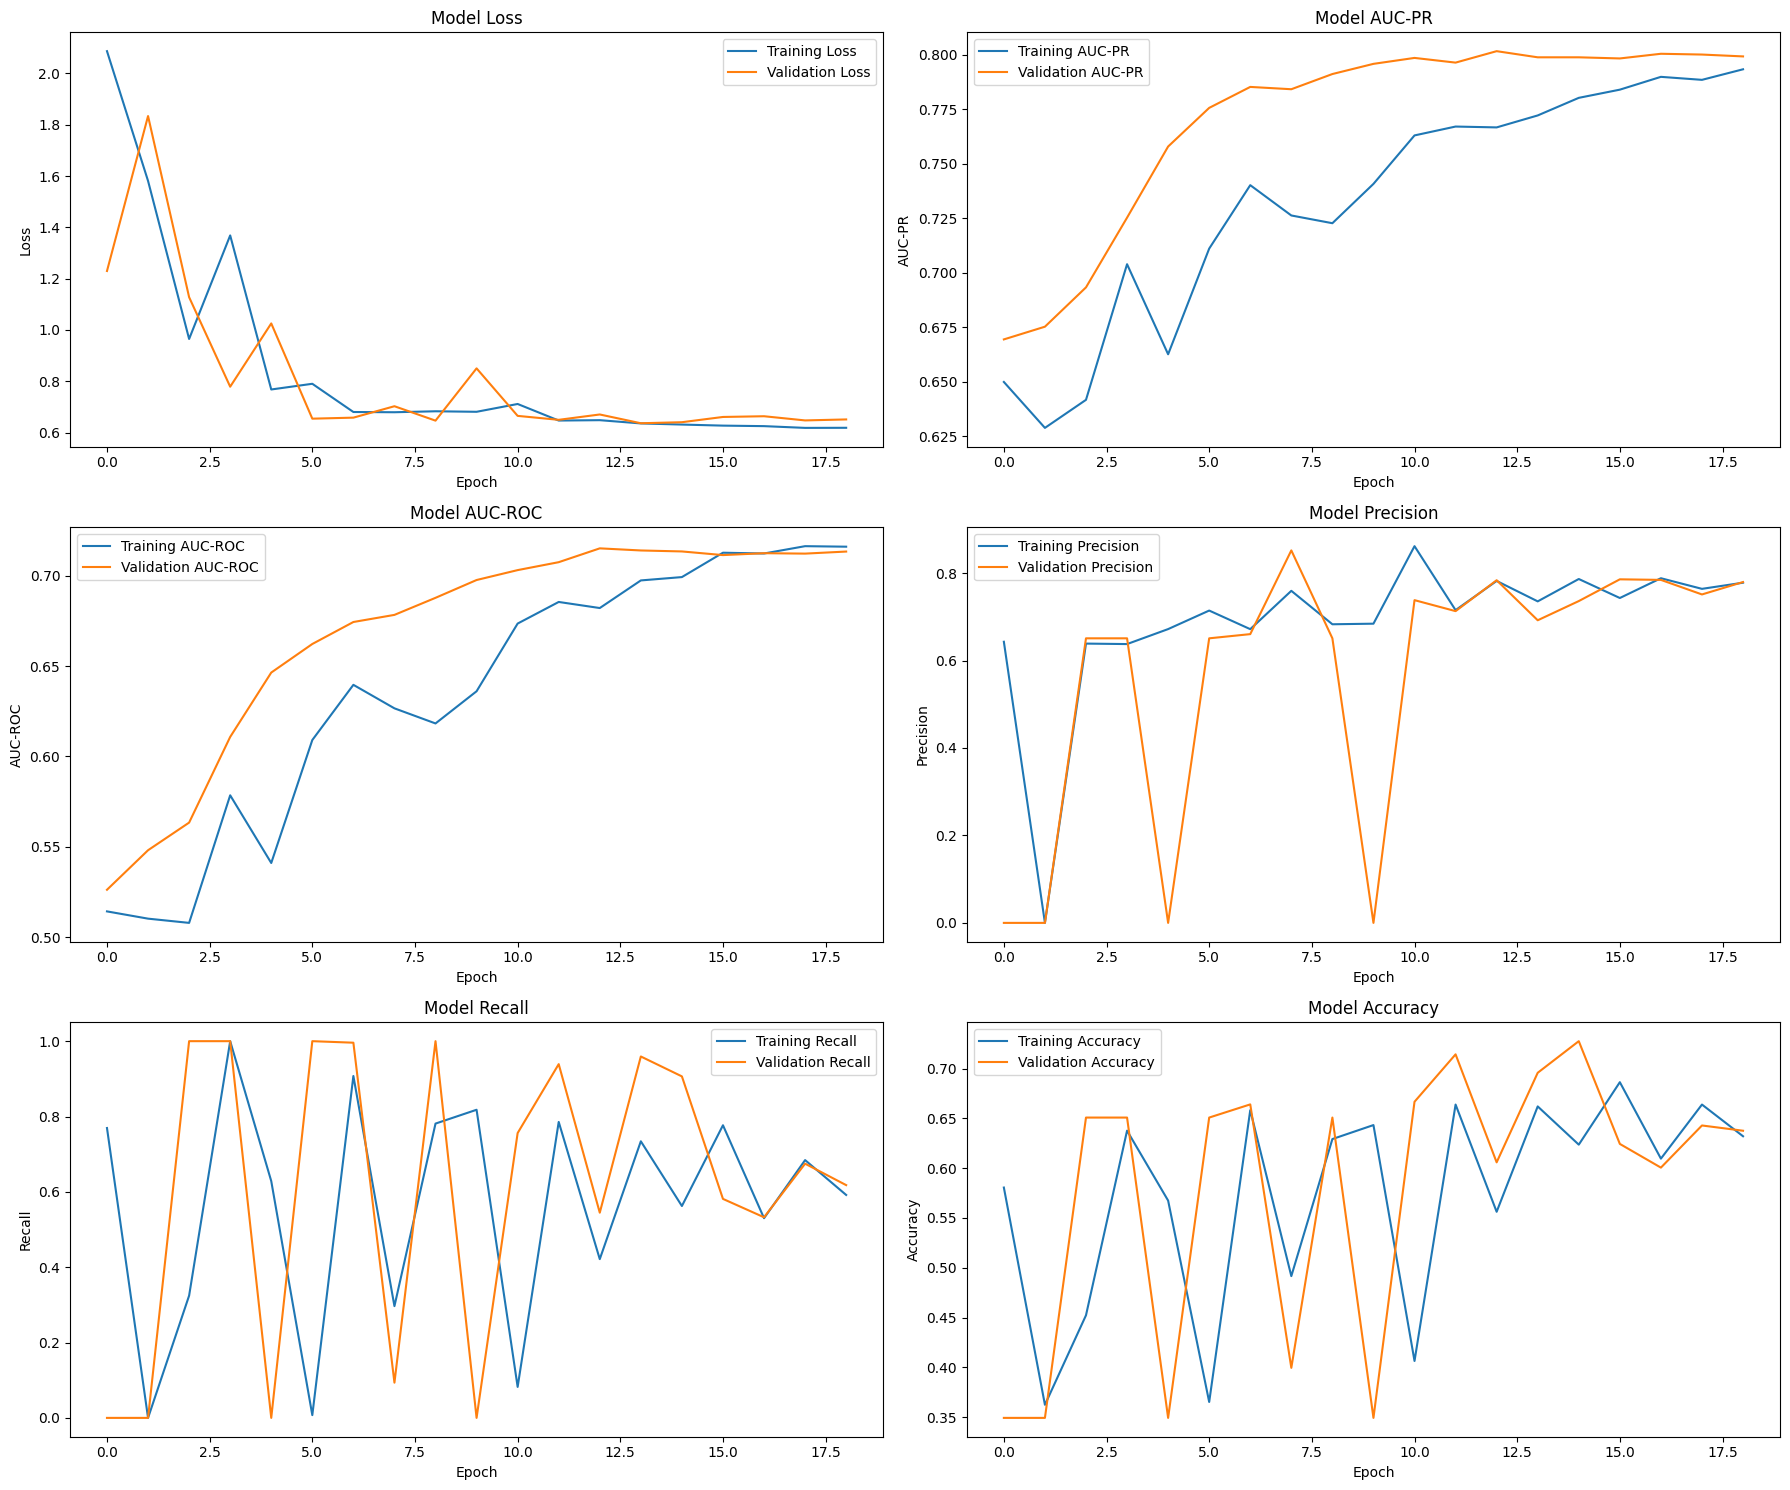

<Figure size 640x480 with 0 Axes>

In [20]:
fig, axes = plt.subplots(3, 2, figsize=(18, 15))

axes[0, 0].plot(history['loss'], label='Training Loss')
axes[0, 0].plot(history['val_loss'], label='Validation Loss')
axes[0, 0].set_title('Model Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

if 'auc_pr' in history and 'val_auc_pr' in history:
    axes[0, 1].plot(history['auc_pr'], label='Training AUC-PR')
    axes[0, 1].plot(history['val_auc_pr'], label='Validation AUC-PR')
    axes[0, 1].set_title('Model AUC-PR')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('AUC-PR')
    axes[0, 1].legend()
else:
    axes[0, 1].set_visible(False)

if 'auc_roc' in history and 'val_auc_roc' in history:
    axes[1, 0].plot(history['auc_roc'], label='Training AUC-ROC')
    axes[1, 0].plot(history['val_auc_roc'], label='Validation AUC-ROC')
    axes[1, 0].set_title('Model AUC-ROC')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('AUC-ROC')
    axes[1, 0].legend()
else:
    axes[1, 0].set_visible(False)

if 'precision' in history and 'val_precision' in history:
    axes[1, 1].plot(history['precision'], label='Training Precision')
    axes[1, 1].plot(history['val_precision'], label='Validation Precision')
    axes[1, 1].set_title('Model Precision')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Precision')
    axes[1, 1].legend()
else:
    axes[1, 1].set_visible(False)

if 'recall' in history and 'val_recall' in history:
    axes[2, 0].plot(history['recall'], label='Training Recall')
    axes[2, 0].plot(history['val_recall'], label='Validation Recall')
    axes[2, 0].set_title('Model Recall')
    axes[2, 0].set_xlabel('Epoch')
    axes[2, 0].set_ylabel('Recall')
    axes[2, 0].legend()
else:
    axes[2, 0].set_visible(False)

if 'accuracy' in history and 'val_accuracy' in history:
    axes[2, 1].plot(history['accuracy'], label='Training Accuracy')
    axes[2, 1].plot(history['val_accuracy'], label='Validation Accuracy')
    axes[2, 1].set_title('Model Accuracy')
    axes[2, 1].set_xlabel('Epoch')
    axes[2, 1].set_ylabel('Accuracy')
    axes[2, 1].legend()
else:
    axes[2, 1].set_visible(False)

plt.tight_layout()
plt.show()

# Save the main plot
plt.savefig(MODEL_RESULTS_FOLDER / f'training_history.png', dpi=300, bbox_inches='tight')

In [21]:
y_pred_proba_val = model.predict(X_ts_val)
best_threshold, stats = pick_threshold(y_val, y_pred_proba_val.flatten(), method="macro")
print(f"Best threshold: {best_threshold}")
for k, v in stats.items():
    print(f"Best {k}: {v}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 837ms/step
Best threshold: 0.46236374974250793
Best macro_f1: 0.6811513544067134


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_605
Received: inputs=('Tensor(shape=(32, 101, 60))',)
  warnings.warn(msg)


11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step

/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_605
Received: inputs=('Tensor(shape=(None, 101, 60))',)
  warnings.warn(msg)


12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 496ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step
MODEL EVALUATION RESULTS
=== Test Prevalence: 61.04 ===
Test AUC-PR : 0.6992
Test AUC-ROC : 0.6075
=== Threshold Dependent Metrics ===
=== Threshold: 0.46 ===
Test Accuracy : 0.6213
Test F1-Macro Score : 0.5351
Test Precision : 0.6412
Test Recall : 0.8616

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Injured       0.64      0.86      0.74       224
 Not Injured       0.53      0.24      0.33       143

    accuracy                           0.62       367
   macro avg       0.59      0.55      0.54       367
weighted avg       0.60      0.62      0.58       367



<Figure size 640x480 with 0 Axes>

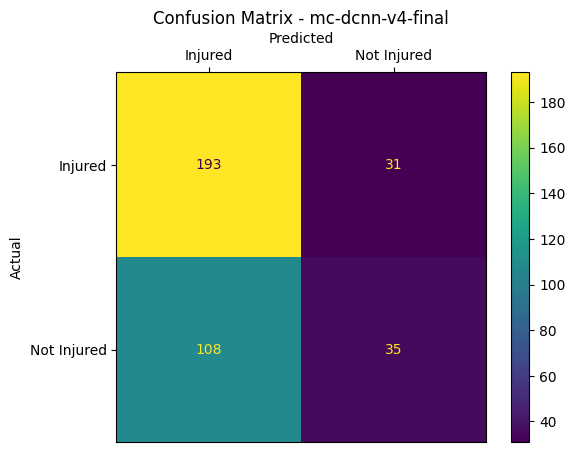

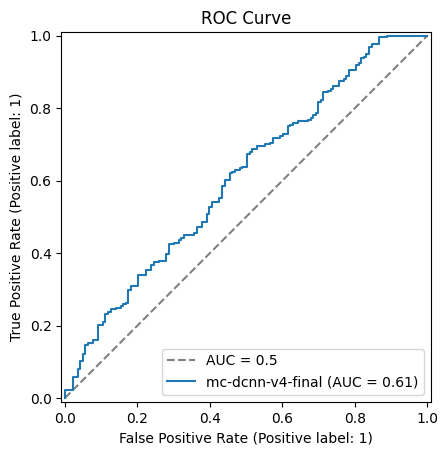

<Figure size 640x480 with 0 Axes>

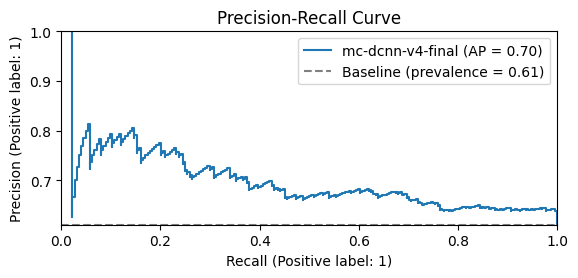

In [22]:
pred = BilateralSingleInputPredictor(model)
test_summary = model_test_summary(model, X_ts_test, y_test, threshold=best_threshold, predictor=pred)

In [23]:
# Save the trained model
if SAVE_MODEL:
    model_loader.save_keras_model_to_disk()
    
    # Save scalers for future use
    scalers = {
        'timeseries_scaler': scaler_ts,
    }
    model_loader.save_scalers_to_disk(scalers)

    # Save training results
    results = {
        'test_accuracy': float(test_summary['accuracy']),
        'test_f1': float(test_summary['f1']),
        'tes_avg_precision': float(test_summary['auc_pr']),
        'test_auc_roc': float(test_summary['auc_roc']),
        'test_precision': float(test_summary['precision']),
        'test_recall': float(test_summary['recall']),   
        'test_prevalence': float(test_summary['prevalence']),
        'threshold': float(test_summary['threshold']),
        'model_name': MODEL_NAME,
        'training_params': {
            "epochs": model.history.params['epochs'],
            'epochs_run': len(model.history.epoch),
            'history': model.history.history,
            'batch_size': BATCH_SIZE,
            'learning_rate': float(model.optimizer.learning_rate.numpy()),
            'dropout_rate': next((layer.rate for layer in model.layers if hasattr(layer, 'rate')), "N/A"),
            'class_weights': class_weight_dict
        }
    }
    model_loader.save_results_to_disk(results)

    print(f"Model and results saved!")

Model and results saved!


## Model Explainability

Let's analyze feature importance using gradient-based saliency maps to understand which features and time points are most important for the model's predictions.


In [24]:
from core.evaluation import (
    compute_timeseries_saliency,
    plot_timeseries_saliency,
    analyze_sample_saliency,
    get_unilateral_feature_names
)

In [25]:
print("Left Side Analysis")
print("="*50)
l_feature_names = get_unilateral_feature_names(channels, side="L")
l_saliency = compute_timeseries_saliency(model, X_ts_test, method="vanilla")
l_results = analyze_sample_saliency(model, [X_ts_test], y_test, l_feature_names)

print("Right Side Analysis")
print("="*50)
r_feature_names = get_unilateral_feature_names(channels, side="R")
r_saliency = compute_timeseries_saliency(model, X_ts_test, method="vanilla")
r_results = analyze_sample_saliency(model, [X_ts_test], y_test, r_feature_names)

Left Side Analysis
Analyzing injured sample (index 0) and healthy sample (index 5)
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step


KeyError: 'pop from an empty set'